General purpose of this page is to give a overview of the theory behind this deep learning framework. this assumes comfort with basic abstract linear algebra concepts (linearity, linear operators, etc), matrix calculus, and a little bit of functional analysis.

If you have linear algebra and calculus background then please visit Matrix Calculus.ipynb before reading this.

Graph Neural Net consists of nodes in a graph I will call N. For this case I will assume DAG but this technique can be extended to cyclic directed graphs with a few modifications in the callstack.

Each $N$ takes a input tensor(s) $p_1,p_2,...$ and outputs another tensor, $G(p)$.
These these nodes $N$ can be composed in ways to get a total model $M(x)$, where $x$ is the input tensor.

You can think of tensors as an n-dimensional array needing n indices to specify a scalar element. vectors are 1d tensors, matrix is 2d.

We use these to preserve structure that makes computation easier for ML

Then we finally have the error function $E(p_{total})$, which gives the total error that we wanna minimize.

General plan is to conduct gradient descent, that is
$p_{total} -= \alpha \nabla E(p_{total})$

The plan is to split the gradient up into its individual parameters with respect to each node N, and have each node calculate its own gradient.

For that we need multivariate chain rule, and a bit of extraction.

**A bit of terminology used here:**

If you have a continuous tensor to scalar function $f(x)$, $f'(x)$ represents the linear operator that takes in $dx$ and outputs the small change

$\frac{\partial f}{\partial x}$ represents the "tensor shadow" that when dot produced with $dx$ gives $df$. This value is typically just called the **gradient** for simplicity's sake, even if the term is a little misused.


That means $\frac{\partial f}{\partial x} \cdot dx = f'(x)[dx] = df$

A tensor dot product is defined similarly to how a vector dot product is: add up the products of same-index elements

$\frac{\partial f}{\partial x} \cdot dx = \sum_{(i,j,k,...)} (\frac{\partial f}{\partial x})_{(i,j,k,...)} \times dx_{(i,j,k,...)}$

In other words, $\frac{\partial f}{\partial x}$ is the dot product representation of the linear operator $f'(x)$. 

This is analogous to how a matrix (paired with matrix multiplication) represents the abstract concept of linear operators from $\R^n$ to $\R^m$

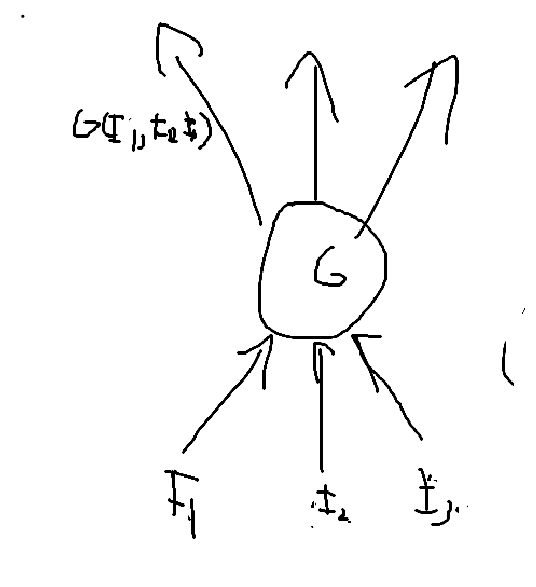

*Example node G*. Note the ingoing edges are the inputes of the node, and outgoing edges represent the output. **All outputs are the same value**

**For each node N**
We can express $E$ in terms of $N(p)$ and therefore $p$ as well.

We will encapsulate the behavior of this node in a class. There will be at least 2 methods, 1 constructor, and 3 variables.

**Types**

**Tensor**: object representing a tensor element

**Terminal**: A specific wrapper class that connects two nodes together.

Contains a **input: Tensor** variable to ensure the back node can pass info forward and a
**gradient: Tensor** to ensure the outgoing node can pass info backwards.
Both will be set to null initially to prevent undefined behavior.

**Variables**
1. **p: Tensor**

This represents the parameters


2. **ingoing_edges: Terminal[]**

A list of references to the public available terminal that all nodes can access. Each element represents one input for the node, and allows for gradient transfer.


3. **outgoing_edges: Terminal[]**

This contains a reference to each input terminal in the outgoing edges, flows info forward and contains all the gradients.

4. **auxiliary parameters as needed**

**Constructor(p_i: Tensor, outgoing_edges: Terminal[], ingoing_edges: Terminal[], auxiliary params)**

The constructor will be used to define the initial parameters of $N$, as well as any other auxiliary parameters as needed.



**Method 1: forward()**

forward prop will take the input from **input_terminal** and output the forward pass, sending a copy of the output each **input** variable in the terminals in **outgoing_edges**

**Method 2: backprop(alpha: scalar)**

The general idea is you can represent the error function $E$ in terms of both $N$ and $p$.

As such, given $\frac{\partial E}{\partial N}$, which we can get by adding all the gradients in **outgoing_edges** (we proved this fact in Matrix Calculus.ipynb).
Now **we set all the gradients in outgoing edges to 0** dont forget this task

we can calculate $\frac{\partial E}{\partial p}$ through the chain rule and the dot product representation:

$\frac{\partial E}{\partial p} \cdot dp = E'(p)[dp] = E'(N)N'(p)[dp] = \frac{\partial E}{\partial N} \cdot (N'(p)[dp])$

$\frac{\partial E}{\partial p} \cdot dp = \frac{\partial E}{\partial N} \cdot dN$

Then we simply subtract $p$ by $\alpha \frac{\partial E}{\partial p}$ to perform gradient descent.

Typically calculating $dN$ is simple, and most of the clever thinking occurs when attempting to extract $\frac{\partial E}{\partial p}$ in a simple and efficient manner.

After performing gradient descent we backpropagate. We do this by calculating the gradient with respect to the input of the nodes $\frac{\partial E}{\partial I_i}$ using the formula above but with I instead of p. Afterwards we backpropagate by setting the gradient contribution in **ingoing_edges**. 

The cycle continuous, working its way backwards in the graph based on a specific order called reverse topological sort.

**Auxilary methods**

These methods exist for a programming purpose. They are meant to be for ease of programming.

The first two methods exist to make unit testing for the gradient easy. They allow outside programs to access internal gradients, a very useful trait needed to test internal gradients.

**Method 1: compute_forward(input: Tensor[]) -> Tensor**

It encapsulates the actual computation of forwardprop for the input

**Method 2: gradient_descend(gradient: Tensor) -> Tensor (aka another Tensor but wtv...)**

It encapsulates the actual computation of backprop, backpropogating the gradient to ensure everything is good.


